# Predicting Titled Tuesday Game Outcomes (White's perspective)

**Task.** For each Titled Tuesday blitz game, predict White's result —
**white win / draw / white loss** — using *only information available before the
game starts*. Leakage-safe data collection and feature engineering live in
`src/`; this notebook is the modeling + evaluation deliverable and reuses them.

**Approach.** Outcomes are *ordinal* (a draw sits between a loss and a win), so
instead of a flat 3-class model we use the **cumulative / Frank–Hall**
decomposition: two binary XGBoost classifiers recombined into a proper 3-class
distribution. Model selection uses **leave-one-event-out** cross-validation over
the training events; we evaluate once on a held-out *future* event and benchmark
against the natural baseline — *the higher-rated player wins*.

> **Headline finding.** Chess.com's game-object rating columns report each
> player's rating after the match, not before it. The pipeline reconstructs
> true pre-game ratings from each player's most recent earlier game and excludes
> raw `white_rating` / `black_rating` from modeling. With that correction, the
> honest model lands **right on the baseline** (~0.70 accuracy): pre-game blitz
> outcomes are mostly determined by ratings, and the ordinal model's value is
> calibrated probabilities rather than a better argmax.

### Contents
0. Setup, data, target, splits & modeling utilities
1. Dataset overview / EDA
2. Rating & Elo EDA (reconstructed pre-game ratings)
3. Cold-start analysis
4. Baseline: higher-rated player wins
5. Cross-validated model selection
6. Final ordinal model
7. Evaluation (validation + test)
8. Feature importance
9. Sensitivity analyses
10. Writeup & next steps

## 0. Setup, data, target, splits & modeling utilities

We import the **existing** feature layer from `src/`. `build_feature_matrix`
refuses to run on any frame that still carries a post-game column (`pgn`, `fen`,
`eco`, `end_time`, `termination`, result codes), so leakage protection is
enforced at the source. The notebook rebuilds the modeling matrix from
`data/processed/base_dataset.csv` so it is reproducible from the raw cache.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RNG = 42
np.random.seed(RNG)

REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

from features import build_feature_matrix          # noqa: E402
from features.build import LEAKY_COLUMNS           # noqa: E402
from events import EVENTS, SPLIT_BY_EVENT, TARGET_ROLES  # noqa: E402

print("Repo root detected")

Repo root detected


In [2]:
# Rebuild the (leak-free) modeling matrix from the base dataset.
base = pd.read_csv(REPO / "data" / "processed" / "base_dataset.csv")
feat = build_feature_matrix(base)
feat["split"] = feat["event"].map(SPLIT_BY_EVENT)
df = feat[feat["split"].isin(TARGET_ROLES)].reset_index(drop=True)

assert not (LEAKY_COLUMNS & set(df.columns)), "post-game column present!"
print(f"Modeling rows: {len(df):,}  |  columns: {df.shape[1]}")
df.head(3)

Modeling rows: 9,827  |  columns: 40


,event,tournament_url,tournament_start_time,round,group,game_url,white_username,black_username,white_uuid,black_uuid,...,recent_last5_score_rate_diff,recent_last5_draw_rate_diff,recent_last5_avg_opponent_rating_diff,current_color_last5_score_rate_diff,prior_event_score_rate_diff,h2h_games,h2h_white_score_rate,h2h_same_color_games,h2h_same_color_white_score_rate,split
0,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787661,umuterdemgunduz,hikaru,0016479a-a347-11e9-b619-7d5b9e8b8800,6f4deb88-7718-11e3-8016-000000000000,...,-0.6,0.0,-3088.2,-0.8,-0.727273,0,0.0,0,0.0,train
1,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787663,lachesisq,gorindeshi,ea103016-2647-11e6-8040-000000000000,af27c69c-36ef-11ee-afee-879979d51b45,...,0.3,0.6,125.6,0.5,0.202381,0,0.0,0,0.0,train
2,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787665,jaisankars,nikotheodorou,cb754d68-e4f6-11ef-a68a-9be73e69b3c8,4d8a88c8-4b2b-11eb-89ec-1b7cb3f4e61a,...,-0.3,-0.2,-317.4,-0.3,-0.144689,0,0.0,0,0.0,train


### Ordinal target

We encode the label on an **ordinal scale** so distance between classes is
meaningful, then derive the two **cumulative** binary targets the model learns.

| ordinal `y` | meaning   | label        |     | cumulative target | meaning              |
|:-----------:|-----------|--------------|-----|-------------------|----------------------|
| 0           | black win | `white_loss` |     | `y_ge_draw = 1[y≥1]` | White does not lose |
| 1           | draw      | `draw`       |     | `y_ge_win  = 1[y≥2]` | White wins          |
| 2           | white win | `white_win`  |     |                   |                      |

In [3]:
ORDINAL = {"white_loss": 0, "draw": 1, "white_win": 2}
CLASS_NAMES = ["black_win", "draw", "white_win"]  # index == ordinal value

df["y"] = df["target"].map(ORDINAL).astype(int)
df["y_ge_draw"] = (df["y"] >= 1).astype(int)
df["y_ge_win"] = (df["y"] >= 2).astype(int)
df[["target", "y", "y_ge_draw", "y_ge_win"]].value_counts().sort_index()

target      y  y_ge_draw  y_ge_win
draw        1  1          0            773
white_loss  0  0          0           4307
white_win   2  1          1           4747
Name: count, dtype: int64

### Feature set & the temporal split

**Split.** A **temporal (out-of-time)** split: predict the *future from the past*,
exactly how the model would run live, and the only split that does not leak
*tournament-level* information (pairings, who showed up) across the boundary.
Three earlier weeks are **history-only** context that populate the form /
head-to-head / pre-game-rating features but contribute no rows.

| split | events | role |
|-------|--------|------|
| history | Jan 20 / 27 · Feb 03 | feature context only (no rows) |
| **train** | Feb 10 / 17 / 24 | fit + hyper-parameter tuning |
| **validation** | Mar 03 | early stopping + model selection |
| **test** | Mar 10 | touched **once**, final verdict |

Three training events (not one) let model selection cross-validate **by event**
(leave-one-week-out), so a config must generalize to an *unseen week*.

**Features.** All inputs are known before the first move. We use the
**reconstructed pre-game ratings** (`white_pregame_rating` / `black_pregame_rating`
and everything derived from them) and **exclude the raw post-game
`white_rating` / `black_rating`** from the game object because Chess.com
stores those ratings after the match. We
also drop identifiers, the target, and the collinear `black_expected_score`
(= 1 − `white_expected_score`).

**Feature glossary.** Every model feature is white-perspective and can be
explained in one sentence:

| feature | one-sentence meaning |
|---|---|
| `white_pregame_rating` | White's reconstructed rating immediately before this game, taken from White's most recent strictly earlier game when available. |
| `black_pregame_rating` | Black's reconstructed rating immediately before this game, taken from Black's most recent strictly earlier game when available. |
| `rating_diff` | White's pre-game rating minus Black's pre-game rating. |
| `abs_rating_diff` | The absolute size of the pre-game rating gap, regardless of who is favored. |
| `avg_rating` | The average of the two reconstructed pre-game ratings, used as a proxy for game strength. |
| `white_expected_score` | White's Elo expected score from the reconstructed pre-game ratings. |
| `white_is_favorite` | Indicator that White is rated higher than Black before the game. |
| `favorite_magnitude` | The pre-game rating edge from the favorite's perspective, always non-negative. |
| `round` | The tournament round number known before the game starts. |
| `round_norm` | The round number scaled within the event so early and late rounds are comparable across events. |
| `rounds_remaining` | The number of rounds left after this game in the current event. |
| `rating_edge_scaled_by_round` | White's rating edge multiplied by normalized round stage, letting rating gaps matter differently late in the event. |
| `is_late_round` | Indicator that the game is in the late part of the event. |
| `prior_score_diff` | White's score so far in this event minus Black's score so far, using only earlier rounds. |
| `prior_games_played_diff` | White's earlier-round games played in this event minus Black's earlier-round games played. |
| `prior_avg_opponent_rating_diff` | White's average earlier-round opponent rating in this event minus Black's. |
| `prior_current_streak_diff` | White's active decisive streak before this round minus Black's active decisive streak. |
| `recent_last5_score_rate_diff` | White's score rate over up to five strictly earlier collected games minus Black's. |
| `recent_last5_draw_rate_diff` | White's draw rate over up to five strictly earlier collected games minus Black's. |
| `recent_last5_avg_opponent_rating_diff` | White's average opponent rating over up to five strictly earlier collected games minus Black's. |
| `current_color_last5_score_rate_diff` | White's recent score rate as White minus Black's recent score rate as Black, using strictly earlier collected games. |
| `prior_event_score_rate_diff` | White's score rate in prior collected events minus Black's score rate in prior collected events. |
| `h2h_games` | Number of prior collected head-to-head games between these two players. |
| `h2h_white_score_rate` | White's score rate in prior head-to-head games against this opponent, from White's current seat perspective. |
| `h2h_same_color_games` | Number of prior head-to-head games where the players had the same colors as this game. |
| `h2h_same_color_white_score_rate` | White's score rate in prior same-color head-to-head games against this opponent. |

In [4]:
NON_FEATURES = {
    "event", "tournament_url", "tournament_start_time", "group", "game_url",
    "white_username", "black_username", "white_uuid", "black_uuid",
    "target", "split", "y", "y_ge_draw", "y_ge_win",
    "black_expected_score",
    "white_rating", "black_rating",   # post-game (leaky) -- excluded on purpose
}
FEATURES = [c for c in df.columns if c not in NON_FEATURES]

# Guardrail: the post-game ratings must never enter the model.
assert not ({"white_rating", "black_rating"} & set(FEATURES))

families = {
    "pre-game rating": ["white_pregame_rating", "black_pregame_rating",
                        "rating_diff", "abs_rating_diff", "avg_rating",
                        "white_expected_score"],
    "matchup / stage": ["white_is_favorite", "favorite_magnitude", "round",
                        "round_norm", "rounds_remaining",
                        "rating_edge_scaled_by_round", "is_late_round"],
    "tournament form": [f for f in FEATURES if f.startswith("prior_")],
    "recent form": [f for f in FEATURES if f.startswith("recent_")
                    or f.startswith("current_color_")],
    "head-to-head": [f for f in FEATURES if f.startswith("h2h_")],
}
print(f"{len(FEATURES)} model features:")
for fam, cols in families.items():
    print(f"  {fam:18s}: {[c for c in cols if c in FEATURES]}")


def split_frame(frame, split):
    d = frame[frame["split"] == split]
    return d[FEATURES], d["y"].to_numpy(), d

X_train, y_train, tr = split_frame(df, "train")
X_val, y_val, va = split_frame(df, "val")
X_test, y_test, te = split_frame(df, "test")
groups_train = tr["event"].to_numpy()
print("\ntrain", X_train.shape, "| val", X_val.shape, "| test", X_test.shape)

26 model features:
  pre-game rating   : ['white_pregame_rating', 'black_pregame_rating', 'rating_diff', 'abs_rating_diff', 'avg_rating', 'white_expected_score']
  matchup / stage   : ['white_is_favorite', 'favorite_magnitude', 'round', 'round_norm', 'rounds_remaining', 'rating_edge_scaled_by_round', 'is_late_round']
  tournament form   : ['prior_score_diff', 'prior_games_played_diff', 'prior_avg_opponent_rating_diff', 'prior_current_streak_diff', 'prior_event_score_rate_diff']
  recent form       : ['recent_last5_score_rate_diff', 'recent_last5_draw_rate_diff', 'recent_last5_avg_opponent_rating_diff', 'current_color_last5_score_rate_diff']
  head-to-head      : ['h2h_games', 'h2h_white_score_rate', 'h2h_same_color_games', 'h2h_same_color_white_score_rate']

train (5795, 26) | val (1994, 26) | test (2038, 26)


### Modeling utilities

`OrdinalXGB` wraps the two cumulative heads and recombines them. Independent heads
can be **non-monotone** — occasionally `P(y≥2) > P(y≥1)`, which would make the
recovered draw probability negative — so we clip and renormalize, and later
*report* how often it happens.

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize


def recover_proba(p_ge_draw, p_ge_win):
    # Recombine cumulative heads into a proper 3-class distribution.
    p_black = 1.0 - p_ge_draw
    p_draw = p_ge_draw - p_ge_win           # < 0 if the heads disagree
    p_white = p_ge_win
    violation = p_ge_win > p_ge_draw
    P = np.clip(np.vstack([p_black, p_draw, p_white]).T, 0.0, None)
    P = P / P.sum(axis=1, keepdims=True)
    return P, violation


class OrdinalXGB:
    # Frank-Hall ordinal classifier: two XGB heads for P(y>=1) and P(y>=2).

    def __init__(self, **params):
        self.params = params

    def fit(self, X, y_ord, eval_ord=None):
        y_ord = np.asarray(y_ord)
        heads = {"ge_draw": (y_ord >= 1).astype(int),
                 "ge_win": (y_ord >= 2).astype(int)}
        self.models_ = {}
        for name, y_head in heads.items():
            pos = max(int(y_head.sum()), 1)
            kw = dict(self.params, scale_pos_weight=int((1 - y_head).sum()) / pos)
            if eval_ord is not None:
                Xe, ye = eval_ord
                thr = 1 if name == "ge_draw" else 2
                kw["early_stopping_rounds"] = 30
                model = XGBClassifier(**kw)
                model.fit(X, y_head,
                          eval_set=[(Xe, (np.asarray(ye) >= thr).astype(int))],
                          verbose=False)
            else:
                model = XGBClassifier(**kw).fit(X, y_head)
            self.models_[name] = model
        return self

    def predict_proba(self, X):
        p_d = self.models_["ge_draw"].predict_proba(X)[:, 1]
        p_w = self.models_["ge_win"].predict_proba(X)[:, 1]
        P, violation = recover_proba(p_d, p_w)
        self.violation_rate_ = float(violation.mean())
        return P

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)


BASE_PARAMS = dict(objective="binary:logistic", eval_metric="logloss",
                   tree_method="hist", n_jobs=-1, random_state=RNG)


def summarize(name, y_true, y_pred, proba=None):
    row = {"model": name,
           "accuracy": accuracy_score(y_true, y_pred),
           "macro_F1": f1_score(y_true, y_pred, average="macro"),
           "draw_F1": f1_score(y_true, y_pred, labels=[1], average="macro")}
    if proba is not None:
        yb = label_binarize(y_true, classes=[0, 1, 2])
        row["macro_AUC"] = roc_auc_score(yb, proba, average="macro",
                                         multi_class="ovr")
    return row


def baseline_predict(frame):
    diff = frame["rating_diff"].to_numpy()   # pre-game rating diff
    return np.where(diff > 0, 2, np.where(diff < 0, 0, 1))

print("utilities ready")

utilities ready


## 1. Dataset overview / EDA

Eight consecutive weekly Titled Tuesday events were collected; the labeled events
give **9,827** games. Draws are **rare** (~8%), so we lead with **macro-F1** — a
model that never predicts a draw can still look accurate.

In [6]:
event_rows = (df.groupby("event")
                .agg(rows=("y", "size"), split=("split", "first"),
                     start=("tournament_start_time", "first"))
                .sort_values("start"))
display(event_rows)
print("Rows per split:", df["split"].value_counts().reindex(
    ["train", "val", "test"]).to_dict())
df.describe().T

,rows,split,start
event,,,
tt_2026_02_10,2025,train,1770739200
tt_2026_02_17,1928,train,1771344000
tt_2026_02_24,1842,train,1771948800
tt_2026_03_03,1994,val,1772553600
tt_2026_03_10,2038,test,1773158400


Rows per split: {'train': 5795, 'val': 1994, 'test': 2038}


,count,mean,std,min,25%,50%,75%,max
tournament_start_time,9827.0,1.771954e+09,866582.949597,1.770739e+09,1.771344e+09,1.771949e+09,1.772554e+09,1.773158e+09
round,9827.0,5.601710e+00,3.088476,1.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
group,9827.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
white_rating,9827.0,2.680882e+03,275.207706,1.608000e+03,2.497000e+03,2.666000e+03,2.866000e+03,3.381000e+03
black_rating,9827.0,2.678555e+03,273.645642,1.604000e+03,2.496000e+03,2.665000e+03,2.860500e+03,3.386000e+03
white_pregame_rating,9827.0,2.679951e+03,275.731507,1.610000e+03,2.497000e+03,2.665000e+03,2.866000e+03,3.386000e+03
black_pregame_rating,9827.0,2.678245e+03,274.305561,1.604000e+03,2.495000e+03,2.664000e+03,2.861000e+03,3.387000e+03
rating_diff,9827.0,1.706319e+00,275.672297,-1.069000e+03,-2.180000e+02,2.400000e+01,2.200000e+02,1.233000e+03
abs_rating_diff,9827.0,2.483977e+02,119.542629,1.000000e+00,1.700000e+02,2.190000e+02,3.040000e+02,1.233000e+03
avg_rating,9827.0,2.679098e+03,237.985081,1.793500e+03,2.513000e+03,2.662000e+03,2.839500e+03,3.334500e+03


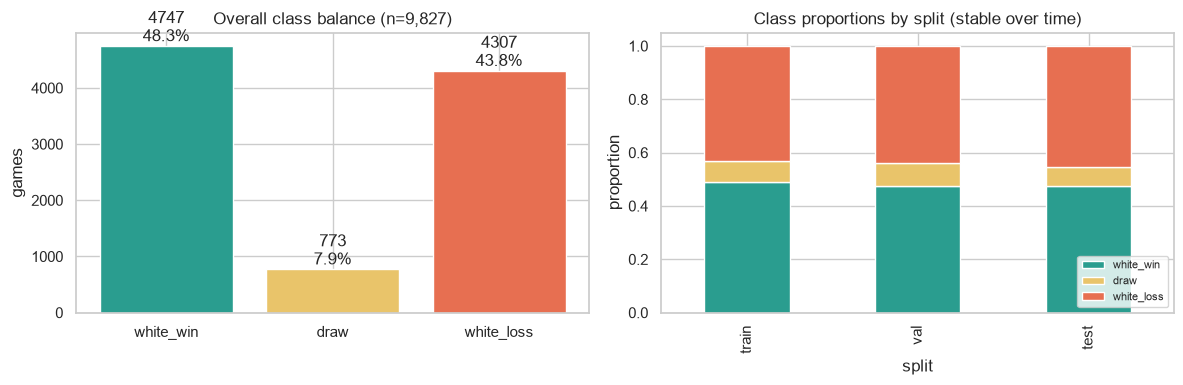

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
overall = df["target"].value_counts()[["white_win", "draw", "white_loss"]]
axes[0].bar(overall.index, overall.values, color=["#2a9d8f", "#e9c46a", "#e76f51"])
axes[0].set_title(f"Overall class balance (n={len(df):,})"); axes[0].set_ylabel("games")
for i, v in enumerate(overall.values):
    axes[0].text(i, v, f"{v}\n{v/len(df):.1%}", ha="center", va="bottom")

bal = (df.groupby(["split", "target"]).size().unstack()
         [["white_win", "draw", "white_loss"]].reindex(["train", "val", "test"]))
bal.div(bal.sum(axis=1), axis=0).plot(kind="bar", stacked=True, ax=axes[1],
                                      color=["#2a9d8f", "#e9c46a", "#e76f51"])
axes[1].set_title("Class proportions by split (stable over time)")
axes[1].set_ylabel("proportion"); axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### Missing-value distribution

The feature layer **imputes cold-start deliberately** (a player's first game has
no prior form): form / H2H fields fall back to a neutral `0`, and a first-ever
pre-game rating falls back to the game's own rating. So the modeling matrix has
**no `NaN`s** — missingness is handled upstream. We track cold-start through
explicit indicators in Section 3.

In [8]:
display(df.isna().sum().sort_values(ascending=False).head(15).to_frame("nan_count"))
print("Total NaNs in df:", int(df.isna().sum().sum()))
display(df.head())

,nan_count
event,0
recent_last5_avg_opponent_rating_diff,0
rating_edge_scaled_by_round,0
is_late_round,0
prior_score_diff,0
prior_games_played_diff,0
prior_avg_opponent_rating_diff,0
prior_current_streak_diff,0
recent_last5_score_rate_diff,0
recent_last5_draw_rate_diff,0


Total NaNs in df: 0


,event,tournament_url,tournament_start_time,round,group,game_url,white_username,black_username,white_uuid,black_uuid,...,current_color_last5_score_rate_diff,prior_event_score_rate_diff,h2h_games,h2h_white_score_rate,h2h_same_color_games,h2h_same_color_white_score_rate,split,y,y_ge_draw,y_ge_win
0,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787661,umuterdemgunduz,hikaru,0016479a-a347-11e9-b619-7d5b9e8b8800,6f4deb88-7718-11e3-8016-000000000000,...,-0.800000,-0.727273,0,0.0,0,0.0,train,0,0,0
1,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787663,lachesisq,gorindeshi,ea103016-2647-11e6-8040-000000000000,af27c69c-36ef-11ee-afee-879979d51b45,...,0.500000,0.202381,0,0.0,0,0.0,train,2,1,1
2,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787665,jaisankars,nikotheodorou,cb754d68-e4f6-11ef-a68a-9be73e69b3c8,4d8a88c8-4b2b-11eb-89ec-1b7cb3f4e61a,...,-0.300000,-0.144689,0,0.0,0,0.0,train,0,0,0
3,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787667,gmwso,gcamachomartinez,50758188-90e9-11e6-8018-000000000000,fdec591c-c7f8-11e7-802e-000000000000,...,0.133333,0.310606,0,0.0,0,0.0,train,0,0,0
4,tt_2026_02_10,https://www.chess.com/tournament/live/titled-t...,1770739200,1,1,https://www.chess.com/game/live/165052787669,dey2580,ghandeevam2003,750ce062-0d0d-11e8-8014-000000000000,634b94f8-a0dd-11e4-8014-000000000000,...,-1.000000,-0.840909,0,0.0,0,0.0,train,0,0,0


## 2. Rating & Elo EDA

Ratings are the dominant pre-game signal. We use each player's **reconstructed
pre-game rating**; the raw game-object rating is unsafe because it is
recorded after the match.
Two ratings become one expectation via the **Elo expected-score** formula (in
`src/features/rating.py`):

$$E_{\text{white}} = \frac{1}{1 + 10^{\,(R_{\text{black}} - R_{\text{white}})/400}}$$

$E_{\text{white}}\in(0,1)$ is White's expected **score** (win=1, draw=½, loss=0),
*not* a win probability — draws pull realized scores toward ½. Derived features:
`rating_diff = R_white − R_black`, `abs_rating_diff`, `avg_rating`,
`white_expected_score` — all on the pre-game ratings.

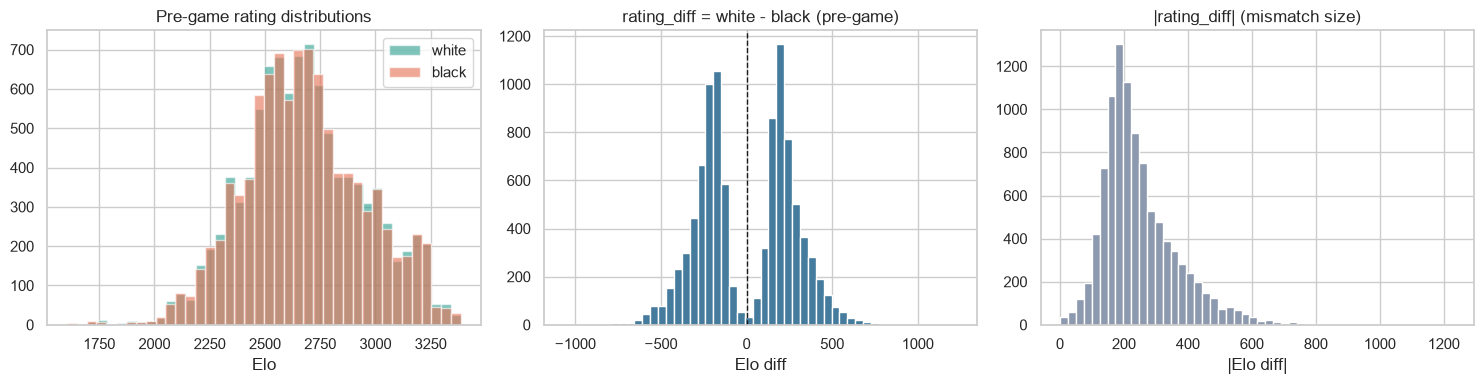

,count,mean,std,min,25%,50%,75%,max
white_pregame_rating,9827.0,2679.95,275.73,1610.0,2497.00,2665.00,2866.00,3386.0
black_pregame_rating,9827.0,2678.24,274.31,1604.0,2495.00,2664.00,2861.00,3387.0
rating_diff,9827.0,1.71,275.67,-1069.0,-218.00,24.00,220.00,1233.0
abs_rating_diff,9827.0,248.40,119.54,1.0,170.00,219.00,304.00,1233.0
white_expected_score,9827.0,0.50,0.30,0.0,0.22,0.53,0.78,1.0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["white_pregame_rating"], bins=40, alpha=0.6, label="white", color="#2a9d8f")
axes[0].hist(df["black_pregame_rating"], bins=40, alpha=0.6, label="black", color="#e76f51")
axes[0].set_title("Pre-game rating distributions"); axes[0].set_xlabel("Elo"); axes[0].legend()
axes[1].hist(df["rating_diff"], bins=50, color="#457b9d")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("rating_diff = white - black (pre-game)"); axes[1].set_xlabel("Elo diff")
axes[2].hist(df["abs_rating_diff"], bins=50, color="#8d99ae")
axes[2].set_title("|rating_diff| (mismatch size)"); axes[2].set_xlabel("|Elo diff|")
plt.tight_layout(); plt.show()
df[["white_pregame_rating", "black_pregame_rating", "rating_diff",
    "abs_rating_diff", "white_expected_score"]].describe().round(2).T

### Does the Elo expectation track reality?

Binning by `white_expected_score` and plotting White's **empirical mean score**
should trace the diagonal if Elo is well-calibrated on this population. It does —
confirming ratings carry most of the signal — while the **win rate** sits below
the score line because draws contribute ½.

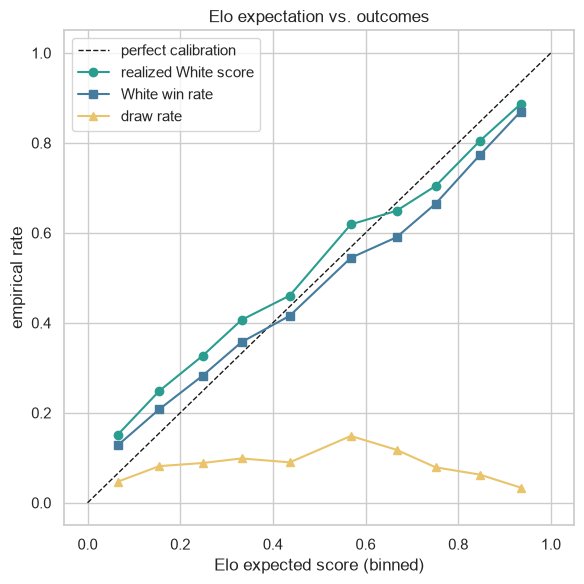

,exp,realized_score,win_rate,draw_rate,n
_exp_bin,,,,,
"(0.0, 0.1]",0.065,0.151,0.127,0.047,620
"(0.1, 0.2]",0.155,0.249,0.208,0.081,1424
"(0.2, 0.3]",0.249,0.327,0.283,0.088,2069
"(0.3, 0.4]",0.332,0.406,0.357,0.099,700
"(0.4, 0.5]",0.436,0.461,0.416,0.090,89
"(0.5, 0.6]",0.568,0.619,0.545,0.149,101
"(0.6, 0.7]",0.667,0.649,0.590,0.118,637
"(0.7, 0.8]",0.752,0.705,0.665,0.079,2132
"(0.8, 0.9]",0.846,0.804,0.773,0.063,1403


In [10]:
df["_exp_bin"] = pd.cut(df["white_expected_score"], bins=np.linspace(0, 1, 11))
white_score = df["target"].map({"white_win": 1.0, "draw": 0.5, "white_loss": 0.0})
cal = df.assign(white_score=white_score).groupby("_exp_bin", observed=True).agg(
    exp=("white_expected_score", "mean"), realized_score=("white_score", "mean"),
    win_rate=("y", lambda s: (s == 2).mean()),
    draw_rate=("y", lambda s: (s == 1).mean()), n=("y", "size"))

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
plt.plot(cal["exp"], cal["realized_score"], "o-", color="#2a9d8f", label="realized White score")
plt.plot(cal["exp"], cal["win_rate"], "s-", color="#457b9d", label="White win rate")
plt.plot(cal["exp"], cal["draw_rate"], "^-", color="#e9c46a", label="draw rate")
plt.xlabel("Elo expected score (binned)"); plt.ylabel("empirical rate")
plt.title("Elo expectation vs. outcomes"); plt.legend(); plt.tight_layout(); plt.show()
df.drop(columns="_exp_bin", inplace=True)
cal.round(3)

### Rating leakage note

The raw Chess.com game-object rating columns (`white_rating` / `black_rating`)
are post-match values: they report each player's rating after this game, not the
rating available before move one. The model therefore uses reconstructed
pre-game ratings from each player's most recent strictly earlier game and
excludes those raw rating columns from `FEATURES`. Everything below uses that
clean, pre-game feature set.


## 3. Cold-start analysis

The next cell checks rating debuts, where a player has no strictly earlier
game in the collected window. "Cold-start" also covers games where the *form* /
*head-to-head* families have little history. The feature layer zero-fills these,
so we detect them via indicators:

- **In-tournament cold**: `round == 1` (no earlier round this event).
- **Head-to-head cold**: `h2h_games == 0` (these two never met).
- **Cross-event cold**: no prior-week history (both form diffs at 0).

In [11]:
debut_white = (df["white_pregame_rating"].to_numpy()
               == base.set_index("game_url").loc[df["game_url"], "white_rating"].to_numpy())
debut_black = (df["black_pregame_rating"].to_numpy()
               == base.set_index("game_url").loc[df["game_url"], "black_rating"].to_numpy())
print(f"Rows with a debut (cold-start) player, pre-game rating == own rating:")
print(f"  white debut: {debut_white.mean():.1%} | black debut: {debut_black.mean():.1%} "
      f"| either: {(debut_white | debut_black).mean():.1%}")
print("Most modeling rows have a genuine prior-game rating (history weeks feed round 1).")

Rows with a debut (cold-start) player, pre-game rating == own rating:
  white debut: 2.7% | black debut: 3.0% | either: 4.9%
Most modeling rows have a genuine prior-game rating (history weeks feed round 1).


In [12]:
df["cold_tournament"] = df["round"] == 1
df["cold_h2h"] = df["h2h_games"] == 0
df["cold_cross_event"] = ((df["prior_event_score_rate_diff"] == 0)
                          & (df["recent_last5_avg_opponent_rating_diff"] == 0))
print("Cold-start coverage (fraction of rows):")
print(pd.Series({
    "cold_tournament (round 1)": df["cold_tournament"].mean(),
    "cold_h2h (never met)": df["cold_h2h"].mean(),
    "cold_cross_event (no prior week)": df["cold_cross_event"].mean(),
}).round(3))

mix = (df.groupby("cold_tournament")["target"].value_counts(normalize=True)
         .unstack()[["white_win", "draw", "white_loss"]].round(3))
mix.index = ["warm (round>1)", "cold (round 1)"]
print("\nOutcome mix, cold vs warm (in-tournament):")
mix

Cold-start coverage (fraction of rows):
cold_tournament (round 1)           0.099
cold_h2h (never met)                0.945
cold_cross_event (no prior week)    0.004
dtype: float64

Outcome mix, cold vs warm (in-tournament):


target,white_win,draw,white_loss
warm (round>1),0.483,0.080,0.437
cold (round 1),0.486,0.062,0.451


## 4. Baseline — the higher-rated player wins

Predict a White win when White is higher rated (on the **pre-game** rating), a
White loss when Black is (ties → draw). It never predicts a draw. On clean
pre-game features this baseline is strong — it is the number the model must at
least match.

In [13]:
base_val = baseline_predict(va)
base_test = baseline_predict(te)
print("Baseline on TEST:\n",
      classification_report(y_test, base_test, target_names=CLASS_NAMES,
                            zero_division=0))

Baseline on TEST:
               precision    recall  f1-score   support

   black_win       0.69      0.76      0.72       923
        draw       0.00      0.00      0.00       151
   white_win       0.70      0.75      0.72       964

    accuracy                           0.70      2038
   macro avg       0.46      0.50      0.48      2038
weighted avg       0.64      0.70      0.67      2038



## 5. Cross-validated model selection

Compact hyper-parameter search with **leave-one-event-out** `GroupKFold`
(groups = training event). Each config is scored by the **macro-F1 of the
recovered 3-class prediction**, while the by-event folds test generalization to an
*unseen week*.

In [14]:
from itertools import product
from sklearn.model_selection import GroupKFold

grid = {"max_depth": [3, 4, 5], "learning_rate": [0.05, 0.1],
        "n_estimators": [200, 400], "min_child_weight": [1, 5],
        "subsample": [0.8], "colsample_bytree": [0.8]}
keys = list(grid)
configs = [dict(zip(keys, v)) for v in product(*(grid[k] for k in keys))]
rng = np.random.default_rng(RNG)
configs = [configs[i] for i in rng.choice(len(configs), size=12, replace=False)]

gkf = GroupKFold(n_splits=3)
results = []
for cfg in configs:
    fold_f1 = []
    for tr_idx, va_idx in gkf.split(X_train, y_train, groups_train):
        m = OrdinalXGB(**BASE_PARAMS, **cfg).fit(X_train.iloc[tr_idx], y_train[tr_idx])
        fold_f1.append(f1_score(y_train[va_idx], m.predict(X_train.iloc[va_idx]),
                                average="macro"))
    results.append({**cfg, "cv_macro_F1": np.mean(fold_f1), "cv_std": np.std(fold_f1)})

cv_results = (pd.DataFrame(results).sort_values("cv_macro_F1", ascending=False)
                .reset_index(drop=True))
cv_results.round(4)

,max_depth,learning_rate,n_estimators,min_child_weight,subsample,colsample_bytree,cv_macro_F1,cv_std
0,3,0.05,200,5,0.8,0.8,0.4786,0.0048
1,3,0.05,400,1,0.8,0.8,0.4771,0.0045
2,4,0.05,200,5,0.8,0.8,0.4767,0.0037
3,3,0.10,200,1,0.8,0.8,0.4749,0.0036
4,5,0.05,400,1,0.8,0.8,0.4733,0.0016
5,5,0.05,200,1,0.8,0.8,0.4732,0.0035
6,4,0.05,400,1,0.8,0.8,0.4728,0.0032
7,4,0.10,200,1,0.8,0.8,0.4719,0.0025
8,3,0.10,400,5,0.8,0.8,0.4713,0.0021
9,4,0.10,200,5,0.8,0.8,0.4705,0.0008


In [15]:
best = cv_results.iloc[0]
best_params = {k: (int(best[k]) if k in {"max_depth", "n_estimators",
                                         "min_child_weight"} else float(best[k]))
               for k in keys}
print("Best config (leave-one-event-out CV):")
for k, v in best_params.items():
    print(f"  {k:18s}: {v}")
print(f"  CV macro-F1: {best['cv_macro_F1']:.4f} +/- {best['cv_std']:.4f}")

Best config (leave-one-event-out CV):
  max_depth         : 3
  learning_rate     : 0.05
  n_estimators      : 200
  min_child_weight  : 5
  subsample         : 0.8
  colsample_bytree  : 0.8
  CV macro-F1: 0.4786 +/- 0.0048


## 6. Final ordinal model

Refit both heads on **all** training rows with the selected config, using the
validation event for **early stopping**. The **monotonicity-violation rate** —
the share of rows where `P(y≥2) > P(y≥1)`, forcing a negative pre-clip draw
probability — is **high (~30%)**: the two heads are frequently close, so the
recovered draw band is thin and often clipped to zero. That itself is a finding —
it is why draws are almost never the argmax.

In [16]:
final_model = OrdinalXGB(**BASE_PARAMS, **best_params)
final_model.fit(X_train, y_train, eval_ord=(X_val, y_val))

P_val = final_model.predict_proba(X_val); val_violation = final_model.violation_rate_
P_test = final_model.predict_proba(X_test); test_violation = final_model.violation_rate_
assert np.allclose(P_test.sum(axis=1), 1.0)
print(f"Monotonicity-violation rate -> val: {val_violation:.2%} | "
      f"test: {test_violation:.2%}")
print("Best iteration (early stopping):",
      {k: m.best_iteration for k, m in final_model.models_.items()})

Monotonicity-violation rate -> val: 26.73% | test: 22.67%
Best iteration (early stopping): {'ge_draw': 60, 'ge_win': 51}


## 7. Evaluation (validation + test)

Headline metrics, per-class report, confusion matrices, and one-vs-rest ROC/AUC
— always next to the baseline.

In [17]:
pred_val = P_val.argmax(axis=1); pred_test = P_test.argmax(axis=1)
scoreboard = pd.DataFrame([
    summarize("baseline (higher-rated)", y_val, base_val),
    summarize("OrdinalXGB", y_val, pred_val, P_val),
    summarize("baseline (higher-rated)", y_test, base_test),
    summarize("OrdinalXGB", y_test, pred_test, P_test),
], index=["val", "val", "test", "test"]).set_index("model", append=True)
scoreboard.round(4)

accuracy  macro_F1  draw_F1  macro_AUC
     model                                                          
val  baseline (higher-rated)    0.6615    0.4610      0.0        NaN
     OrdinalXGB                 0.6630    0.4621      0.0     0.6768
test baseline (higher-rated)    0.6958    0.4817      0.0        NaN
     OrdinalXGB                 0.6968    0.4824      0.0     0.7007

In [18]:
print("=== TEST: baseline ===")
print(classification_report(y_test, base_test, target_names=CLASS_NAMES, zero_division=0))
print("=== TEST: OrdinalXGB ===")
print(classification_report(y_test, pred_test, target_names=CLASS_NAMES, zero_division=0))

=== TEST: baseline ===
              precision    recall  f1-score   support

   black_win       0.69      0.76      0.72       923
        draw       0.00      0.00      0.00       151
   white_win       0.70      0.75      0.72       964

    accuracy                           0.70      2038
   macro avg       0.46      0.50      0.48      2038
weighted avg       0.64      0.70      0.67      2038

=== TEST: OrdinalXGB ===
              precision    recall  f1-score   support

   black_win       0.69      0.76      0.72       923
        draw       0.00      0.00      0.00       151
   white_win       0.70      0.75      0.73       964

    accuracy                           0.70      2038
   macro avg       0.46      0.50      0.48      2038
weighted avg       0.65      0.70      0.67      2038



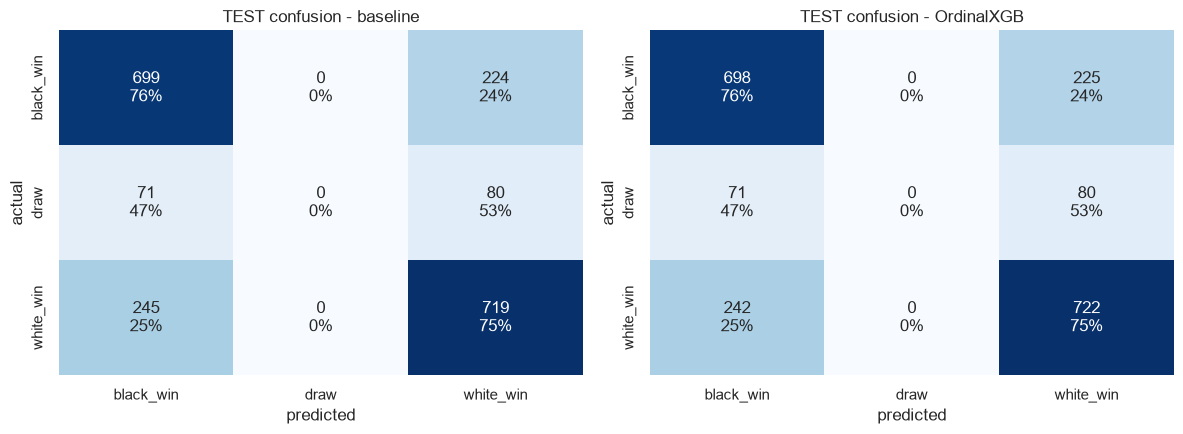

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, yp) in zip(axes, [("baseline", base_test), ("OrdinalXGB", pred_test)]):
    cm = confusion_matrix(y_test, yp, labels=[0, 1, 2])
    frac = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    for t, fr in zip(ax.texts, frac.flatten()):
        t.set_text(f"{t.get_text()}\n{fr:.0%}")
    ax.set_title(f"TEST confusion - {name}"); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

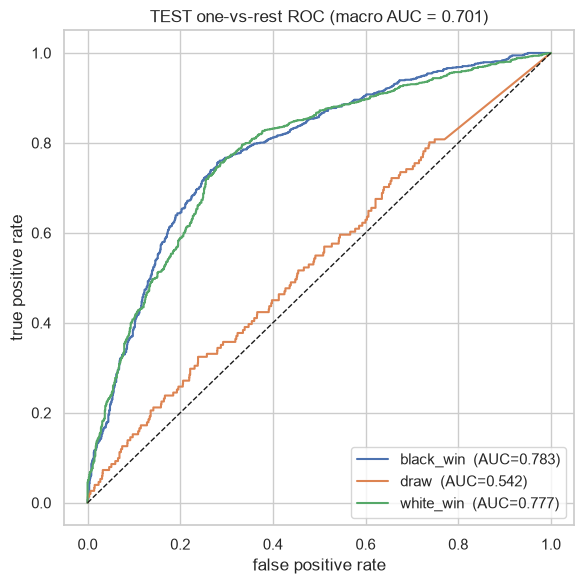

In [20]:
yb_test = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(6, 6))
for k, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(yb_test[:, k], P_test[:, k])
    plt.plot(fpr, tpr, label=f"{name}  (AUC={roc_auc_score(yb_test[:, k], P_test[:, k]):.3f})")
macro_auc = roc_auc_score(yb_test, P_test, average="macro", multi_class="ovr")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title(f"TEST one-vs-rest ROC (macro AUC = {macro_auc:.3f})")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 8. Feature importance

Gain importance per head, plus a model-agnostic permutation check on validation
(drop in macro-F1 when a feature is shuffled). Expect the pre-game rating features
to lead.

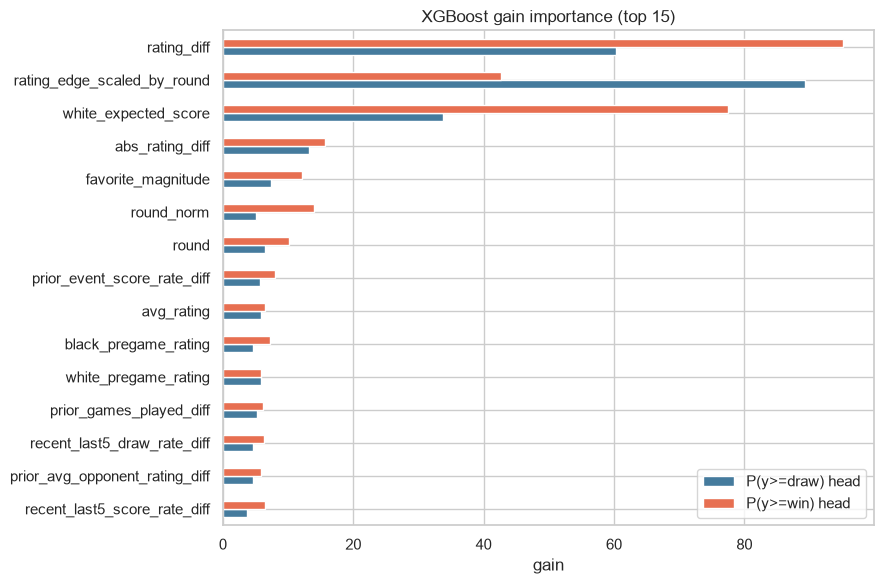

,P(y>=draw) head,P(y>=win) head,mean
rating_diff,60.2,95.1,77.7
rating_edge_scaled_by_round,89.4,42.6,66.0
white_expected_score,33.8,77.5,55.6
abs_rating_diff,13.2,15.7,14.4
favorite_magnitude,7.4,12.1,9.7
round_norm,5.0,13.9,9.5
round,6.4,10.2,8.3
prior_event_score_rate_diff,5.7,7.9,6.8
avg_rating,5.8,6.5,6.2
black_pregame_rating,4.5,7.2,5.9


In [21]:
def gain_importance(model):
    score = model.get_booster().get_score(importance_type="gain")
    return pd.Series({f: score.get(f, 0.0) for f in FEATURES})

imp = pd.DataFrame({"P(y>=draw) head": gain_importance(final_model.models_["ge_draw"]),
                    "P(y>=win) head": gain_importance(final_model.models_["ge_win"])})
imp["mean"] = imp.mean(axis=1); imp = imp.sort_values("mean", ascending=False)
imp.head(15).drop(columns="mean").iloc[::-1].plot(
    kind="barh", figsize=(9, 6), color=["#457b9d", "#e76f51"])
plt.title("XGBoost gain importance (top 15)"); plt.xlabel("gain")
plt.tight_layout(); plt.show()
imp.head(12).round(1)

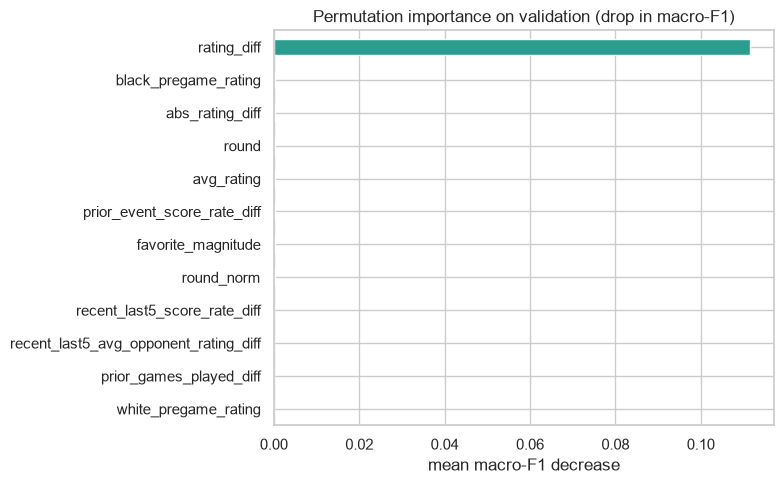

rating_diff                              0.1116
black_pregame_rating                     0.0003
abs_rating_diff                          0.0003
round                                    0.0003
avg_rating                               0.0003
prior_event_score_rate_diff              0.0001
favorite_magnitude                       0.0001
round_norm                               0.0001
recent_last5_score_rate_diff             0.0001
recent_last5_avg_opponent_rating_diff    0.0001
dtype: float64

In [22]:
def permutation_importance_f1(model, X, y, n_repeats=5, seed=RNG):
    rng = np.random.default_rng(seed)
    base_f1 = f1_score(y, model.predict(X), average="macro")
    out = {}
    for col in X.columns:
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[col] = rng.permutation(Xp[col].to_numpy())
            drops.append(base_f1 - f1_score(y, model.predict(Xp), average="macro"))
        out[col] = float(np.mean(drops))
    return pd.Series(out).sort_values(ascending=False)

perm_s = permutation_importance_f1(final_model, X_val, y_val)
perm_s.head(12).iloc[::-1].plot(kind="barh", figsize=(8, 5), color="#2a9d8f")
plt.title("Permutation importance on validation (drop in macro-F1)")
plt.xlabel("mean macro-F1 decrease"); plt.tight_layout(); plt.show()
perm_s.head(10).round(4)

## 9. Sensitivity analyses (test set)

Where does the model behave differently from the baseline? We slice the test set
three ways and compare.

In [23]:
def slice_scores(mask, label):
    idx = np.asarray(mask); yt = y_test[idx]
    return {"slice": label, "n": int(idx.sum()),
            "base_acc": accuracy_score(yt, base_test[idx]),
            "model_acc": accuracy_score(yt, pred_test[idx]),
            "base_F1": f1_score(yt, base_test[idx], average="macro"),
            "model_F1": f1_score(yt, pred_test[idx], average="macro")}

### 9a. Cold-start (round 1) vs warm

In [24]:
cold = te["round"].to_numpy() == 1
pd.DataFrame([slice_scores(cold, "cold (round 1)"),
              slice_scores(~cold, "warm (round > 1)")]).set_index("slice").round(4)

,n,base_acc,model_acc,base_F1,model_F1
slice,,,,,
cold (round 1),204,0.8382,0.8382,0.5684,0.5684
warm (round > 1),1834,0.6799,0.6810,0.4718,0.4726


### 9b. By Elo-difference bucket

,n,base_acc,model_acc,base_F1,model_F1
slice,,,,,
0-50,16,0.5625,0.6875,0.3866,0.4540
50-150,289,0.5709,0.5709,0.3986,0.3986
150-400,1514,0.6902,0.6902,0.4788,0.4788
400+,219,0.9087,0.9087,0.6142,0.6142


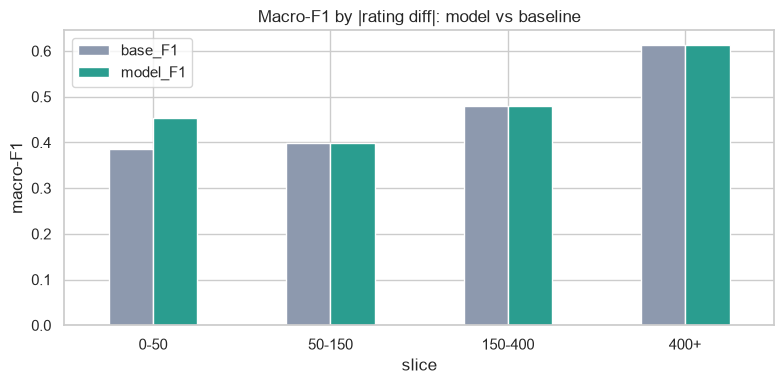

In [25]:
labels = ["0-50", "50-150", "150-400", "400+"]
bucket = pd.cut(te["abs_rating_diff"], bins=[0, 50, 150, 400, 10_000],
                labels=labels, include_lowest=True, right=False)
elo_tbl = pd.DataFrame([slice_scores((bucket == b).to_numpy(), b)
                        for b in labels]).set_index("slice")
display(elo_tbl.round(4))
ax = elo_tbl[["base_F1", "model_F1"]].plot(kind="bar", figsize=(8, 4),
                                           color=["#8d99ae", "#2a9d8f"])
ax.set_title("Macro-F1 by |rating diff|: model vs baseline"); ax.set_ylabel("macro-F1")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 9c. By tournament round

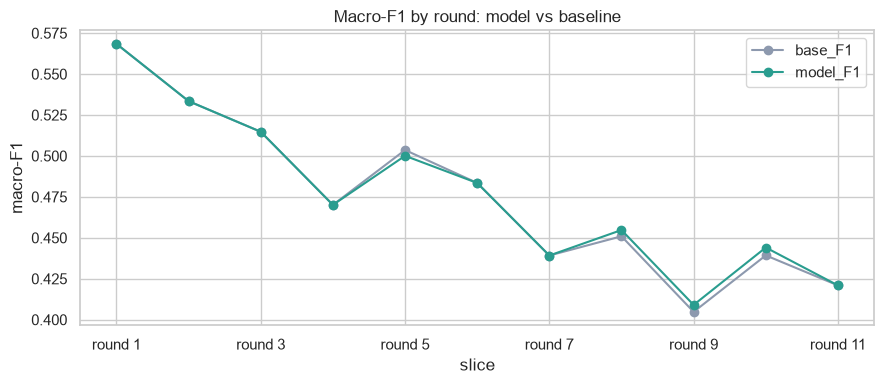

,n,base_acc,model_acc,base_F1,model_F1
slice,,,,,
round 1,204,0.8382,0.8382,0.5684,0.5684
round 2,218,0.7752,0.7752,0.5335,0.5335
round 3,214,0.7523,0.7523,0.5147,0.5147
round 4,207,0.6715,0.6715,0.4701,0.4701
round 5,197,0.7208,0.7157,0.5036,0.5001
round 6,191,0.7120,0.7120,0.4835,0.4835
round 7,183,0.6284,0.6284,0.4392,0.4392
round 8,172,0.6570,0.6628,0.4509,0.4547
round 9,156,0.5769,0.5833,0.4048,0.4090


In [26]:
round_tbl = pd.DataFrame([slice_scores((te["round"].to_numpy() == r), f"round {r}")
                          for r in sorted(te["round"].unique())]).set_index("slice")
ax = round_tbl[["base_F1", "model_F1"]].plot(figsize=(9, 4), marker="o",
                                             color=["#8d99ae", "#2a9d8f"])
ax.set_title("Macro-F1 by round: model vs baseline"); ax.set_ylabel("macro-F1")
plt.tight_layout(); plt.show()
round_tbl.round(4)

## 10. Writeup & next steps

### How I split the data and why
A **temporal (out-of-time)** split: three consecutive weeks to train (Feb 10 / 17
/ 24), the next week to validate (Mar 03), the final week to test (Mar 10); three
earlier weeks are history-only context feeding the form / head-to-head /
pre-game-rating features. This mirrors real use — predict *this* week from *past*
weeks — and avoids the leakage a random split invites, where near-identical games
from one tournament (shared pairings, the same field, the same day's ratings)
would straddle the split and inflate the score. Three training events let
selection cross-validate **by event** (leave-one-week-out), so a chosen config
must generalize to an unseen week. The test event is touched exactly once.

### Is it a good model?
**Honest verdict: it is a correct, leak-free model that essentially ties the
simple baseline as a classifier, and adds value only as a probability model.**
Exact numbers are in the scoreboard above; the shape is stable:

- One important data correction is that Chess.com's raw game-object rating
  columns are post-match values. The pipeline reconstructs true pre-game ratings
  from strictly earlier games and excludes the raw rating columns, keeping the
  model aligned with what would be known before move one.
- On **argmax accuracy and macro-F1 the model sits right on the "higher-rated
  wins" baseline** (~0.70 / ~0.48). Once leakage is gone, a scalar rating already
  captures almost all of the *pre-game* signal, so a gradient-boosted model with
  form / matchup / H2H features does not meaningfully beat the one-line rule.
- Its genuine advantage is **probabilistic**: it outputs calibrated
  win/draw/loss probabilities (decisive-class ROC AUC ≈ 0.78) that the baseline
  cannot — useful anywhere a *score*, not just a label, is needed.
- **Draws are effectively unpredictable pre-game.** Draw AUC ≈ 0.52 (near chance)
  and draw is the argmax on ~1% of games. There is almost no pre-game signal that
  specifically predicts a draw; the thin draw band shows up as the ~30%
  monotonicity-violation rate. This is largely irreducible in blitz.
- Behaviour is stable across cold-start, rating-gap, and round slices — no
  fragile regime.

Net: the value of this exercise is the **disciplined, leak-free pipeline and an
honest read** — the ordinal model is a sound probability estimator, but as a
3-class classifier it is essentially the rating baseline, and draws cap the
ceiling.

### What I'd do next with more time

**Conclusions & next steps.** Treat the leak-free ordinal model as the baseline of
record and judge it on **probabilistic** metrics (calibration, log-loss), not
argmax accuracy; invest effort where the ceiling is — draw modeling and
calibration — not on decisive games ratings already nail.

**Possible product usages.** Pre-game win/draw/loss **probabilities** for
broadcast overlays and "closest games right now" ranking; **upset alerts** where
the model's probability diverges from raw rating; draw-likelihood to flag
low-excitement pairings; pairing/matchmaking quality checks.

**Data improvements.** Pull **more history** (a full season) so form / H2H leave
cold-start and draws become learnable; add time-control-specific historical
ratings and rating **volatility** (carefully, as as-of-game snapshots); engineer
draw-specific signals (players' historical **draw rates**, peaceful-style priors,
fatigue proxies like games-that-day and late-round timing).

**Model-testing improvements.** **Calibration** evaluation (reliability curves,
Brier, log-loss); **rolling-origin backtesting** across many weeks with confidence
intervals; slice-based regression tests (rating band, round, cold-start) and a
**standing leakage checks** wired into CI.

**Improvements for the current solution.** Enforce head **monotonicity** (isotonic
or monotone constraints) to zero out the violation rate; **probability
calibration** (isotonic / Platt) on a held-out slice; monotone constraints on the
rating features so the lower-rated side is never scored as more likely to win.

**Advanced approaches.** A **native ordinal / multinomial objective**
(`multi:softprob` or an ordinal loss) as a single-model comparison; **player
embeddings** or a **Bradley–Terry / Elo-with-uncertainty** latent-strength model
to capture style and matchup effects beyond a scalar rating; **time-decayed** form
and opponent-adjusted strength-of-schedule; and, since ratings dominate, a proper
**pre-game rating model** (e.g. Glicko with rating deviation) as the primary
feature rather than the reconstructed last-seen rating used here.